### <span style="color: rgb(230, 215, 0);"> Sprint 8.1 </span> <span style="color: rgb(230, 0, 126);"> Andrés Vidal Monge </span>
### <span style="color: rgb(230, 215, 0);"> Nivel 1</span> Conexión con Power Bi

In [2]:
# import mysql
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import(is_numeric_dtype, 
                            is_object_dtype, 
                            is_datetime64_any_dtype
                            )

connect = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = '4774',
    database = 'new_transactions'
)

# Use the cursor() method of a MySQLConnection object to create a cursor object to perform various SQL operations.
cursor = connect.cursor()
cursor.execute('SHOW TABLES')
nombres_tablas = [row[0] for row in cursor.fetchall()]

# The execute() methods run the SQL query and returns the result.
# Use cursor.fetchall() or fetchone() or fetchmany() to read query result.
db_new_transactions = {}
for taulas in nombres_tablas:
    cursor.execute(f"select * from {taulas}")
    datos = cursor.fetchall()
    columnas = cursor.column_names
    df = pd.DataFrame(datos, columns = columnas)
    # globals()[f'df_{taulas}'] = df        #se usa globals al copiar el codigo en power bi, en lugar de añadir df al diccionario.
    db_new_transactions[taulas] = df
    
# for taula in nombres_tablas:
#     exec(f'df_{taula}')                   # se activa exec con f'string{}' para crear df de todas las tablas

connect.close()

# para crear un nombre de variable o df dinamico... se usa funcion globals ... Esto permite que Power bi lea todos los df dentro del diccionario

In [3]:


# merge users con transactions para sacar datos numericos, categoricos y de fechas
users = db_new_transactions['users']
transactions = db_new_transactions['transactions']
companies = db_new_transactions['companies']
products = db_new_transactions['products']
products_transactions = db_new_transactions['products_in_transactions']

# merge transactions con usuarios
df_users_transactions = pd.merge(users,transactions,how='left', left_on='id', right_on='user_id')
# merge transactions con companies
df_companies_transactions = pd.merge(companies,transactions, how='left', left_on='company_id', right_on='business_id')
# merge products con transactions
df_productsINtransactions = pd.merge(products_transactions,products, how='inner',left_on='product_id',right_on='id')
df_tran_products = pd.merge(df_productsINtransactions,transactions,how='inner',left_on='transaction_id',right_on='id')

In [4]:
# borrar valores nulos despues de hacer merge entre tablas
df_UsTr_clean = df_users_transactions.dropna(subset=['user_id','amount','country'])


In [6]:
df_companies_transactions

,company_id,company_name,phone,email,country,website,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site,108B1D1D-5B23-A76C-55EF-C568E49A05DD,CcU-2938,b-2222,2021-07-07 17:43:16,293.57,0,59,275,83.78,-178.86
1,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site,EA2C3281-C9C1-A387-44F8-729FB4B51C76,CcU-2938,b-2222,2021-05-09 10:25:08,119.36,1,"59, 79, 37, 73",275,20.20,-116.84
2,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9,7DC26247-20EC-53FE-E555-B6C2E55CA5D5,CcU-2945,b-2226,2022-02-04 15:52:56,312.50,0,"71, 41",275,58.94,-76.82
3,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9,FE96CE47-BD59-381C-4E18-E3CA3D44E8FF,CcU-2945,b-2226,2021-06-15 00:26:29,480.13,1,3,275,-21.88,-112.59
4,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars,72997E96-DC2C-A4D7-7C24-66C302F8AE5A,CcU-2952,b-2230,2022-01-30 15:16:36,239.87,0,"97, 41, 3",275,43.36,-17.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings,DAE50B38-3526-4AAF-71DB-4B45D29EB26A,CcU-3827,b-2618,2021-04-25 12:29:04,309.22,0,"13, 5",259,51.75,114.64
583,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings,DC5ABC81-6D3F-E8CF-29A9-CC136D6EADB8,CcU-3799,b-2618,2022-03-15 02:15:32,101.32,0,"73, 31",261,-6.94,-56.70
584,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings,EAD9435C-77C0-3D84-D9A9-BF535EDABE7A,CcU-3694,b-2618,2021-05-01 18:41:40,113.49,0,"11, 67",267,-45.65,63.62
585,b-2618,Non Institute,06 77 15 31 14,amet.metus@protonmail.couk,United Kingdom,https://guardian.co.uk/settings,EC243849-3D95-A5B3-29B4-6F8AA1A5B999,CcU-3673,b-2618,2021-03-23 02:17:50,38.03,0,"23, 13",267,-43.15,-47.01


In [7]:
empresasPais = df_companies_transactions[df_companies_transactions['amount'] > 400].iloc[:,[0,1,4,8,10,11]]
empresasPais

,company_id,company_name,country,business_id,amount,declined
3,b-2226,Magna A Neque Industries,Australia,b-2226,480.13,1
5,b-2230,Fusce Corp.,United States,b-2230,460.38,1
9,b-2238,Ante Iaculis Nec Foundation,New Zealand,b-2238,401.53,1
18,b-2258,Vestibulum Lorem PC,Belgium,b-2258,439.72,1
19,b-2258,Vestibulum Lorem PC,Belgium,b-2258,428.40,0
...,...,...,...,...,...,...
566,b-2618,Non Institute,United Kingdom,b-2618,468.49,0
569,b-2618,Non Institute,United Kingdom,b-2618,432.21,0
571,b-2618,Non Institute,United Kingdom,b-2618,437.72,0
572,b-2618,Non Institute,United Kingdom,b-2618,492.42,0


In [8]:
empresasPais['declined'] = empresasPais['declined'].astype(bool)

In [9]:
productos40 = df_tran_products[df_tran_products['amount'] > 400].iloc[:,[3,4,6,10,12,13]]
productos40

,product_name,price,weight,business_id,amount,declined
0,Direwolf Stannis,161.11,1.00,b-2362,466.92,0
2,Direwolf Stannis,161.11,1.00,b-2302,497.84,0
5,Direwolf Stannis,161.11,1.00,b-2570,425.64,0
9,Direwolf Stannis,161.11,1.00,b-2618,475.06,0
13,Direwolf Stannis,161.11,1.00,b-2302,417.70,0
...,...,...,...,...,...,...
1430,jinn Winterfell,65.25,1.00,b-2346,444.00,0
1431,jinn Winterfell,65.25,1.00,b-2326,472.18,0
1433,jinn Winterfell,65.25,1.00,b-2454,444.16,0
1437,jinn Winterfell,65.25,1.00,b-2362,460.82,0


In [10]:
productos40.iloc[:,5] = productos40.iloc[:,5].astype(bool)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15948\3032583685.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       False
2       False
5       False
9       False
13      False
        ...  
1430    False
1431    False
1433    False
1437    False
1438     True
Name: declined, Length: 319, dtype: bool' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  productos40.iloc[:,5] = productos40.iloc[:,5].astype(bool)


In [11]:
productos40['amount'] = pd.to_numeric(productos40['amount'])
productos40['price'] = pd.to_numeric(productos40['price'])
productos40['weight'] = pd.to_numeric(productos40['weight'])

In [12]:
productos40.dtypes

product_name     object
price           float64
weight          float64
business_id      object
amount          float64
declined           bool
dtype: object

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 1</span> Una variable numérica.

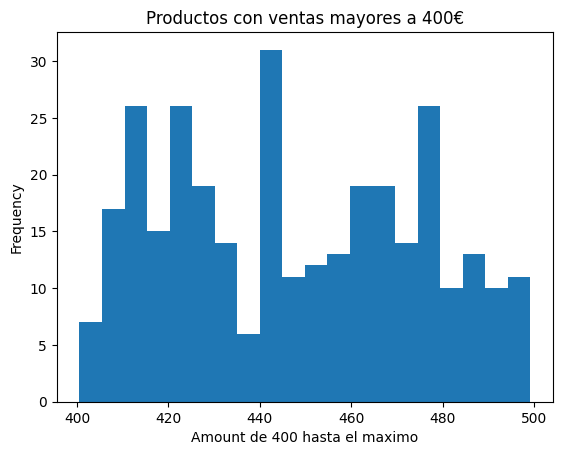

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


productos40 = df_tran_products[df_tran_products['amount'] > 400].iloc[:,[3,4,6,10,12,13]]
productos40['amount'] = pd.to_numeric(productos40['amount'])


users_postal_code = productos40['amount'].plot.hist(bins=20)
plt.title('Productos con ventas mayores a 400€')
plt.xlabel('Amount de 400 hasta el maximo')
plt.show()

dar contexto con los titulos, que veas el grafico y lo entiendas

insigths con comentarios de lso graficos que vemos y comentar los rangos

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 2</span> Dos variables numéricas.

In [14]:
productos40.dtypes

product_name     object
price            object
weight           object
business_id      object
amount          float64
declined          int64
dtype: object

In [15]:
productos40['price'] = pd.to_numeric(productos40['price'])

Text(0.5, 1.0, 'Productos con ventas mayores a 400€')

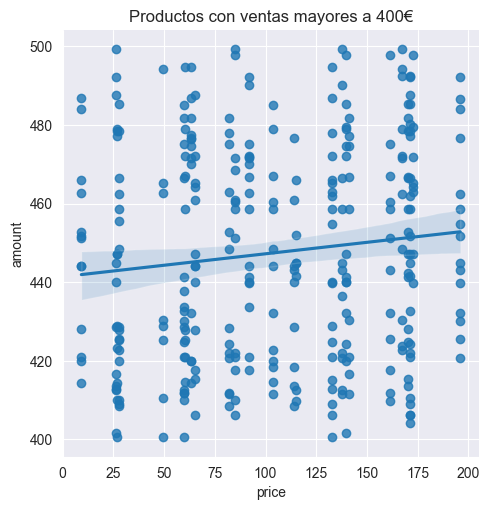

In [16]:
sns.set_style('darkgrid')
sns.lmplot(data=productos40, x='price', y = 'amount')
plt.title('Productos con ventas mayores a 400€')

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 3</span> Una variable categórica.

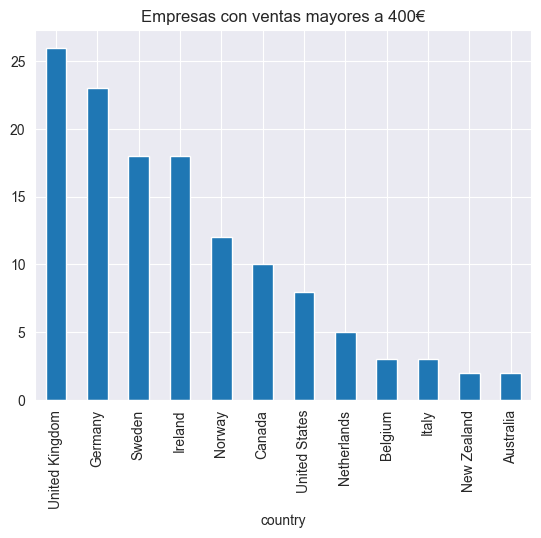

In [18]:
import pandas as pd
import matplotlib.pyplot as plt


empresasPais = df_companies_transactions[df_companies_transactions['amount'] > 400][['company_id','company_name','country','business_id','amount','declined']]

categorica = empresasPais['country'].value_counts()
categorica.plot.bar()
plt.title('Empresas con ventas mayores a 400€')
plt.show()


### <span style="color: rgb(230, 0, 126);"> - Ejercicio 4</span> Una variable categórica y una numérica.

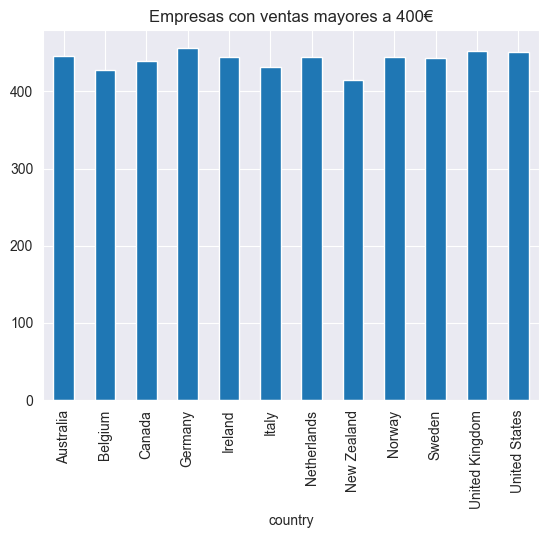

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

empresasPais.groupby('country')['amount'].mean().plot.bar()
plt.title('Empresas con ventas mayores a 400€')
plt.show()

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 5</span> Dos variables categóricas.

ax.legend para cambiar los parametros de la leyenda y la ubicacion. si hay muchos parametros en la leyenda ponerlo por columnas


sns.move_legend

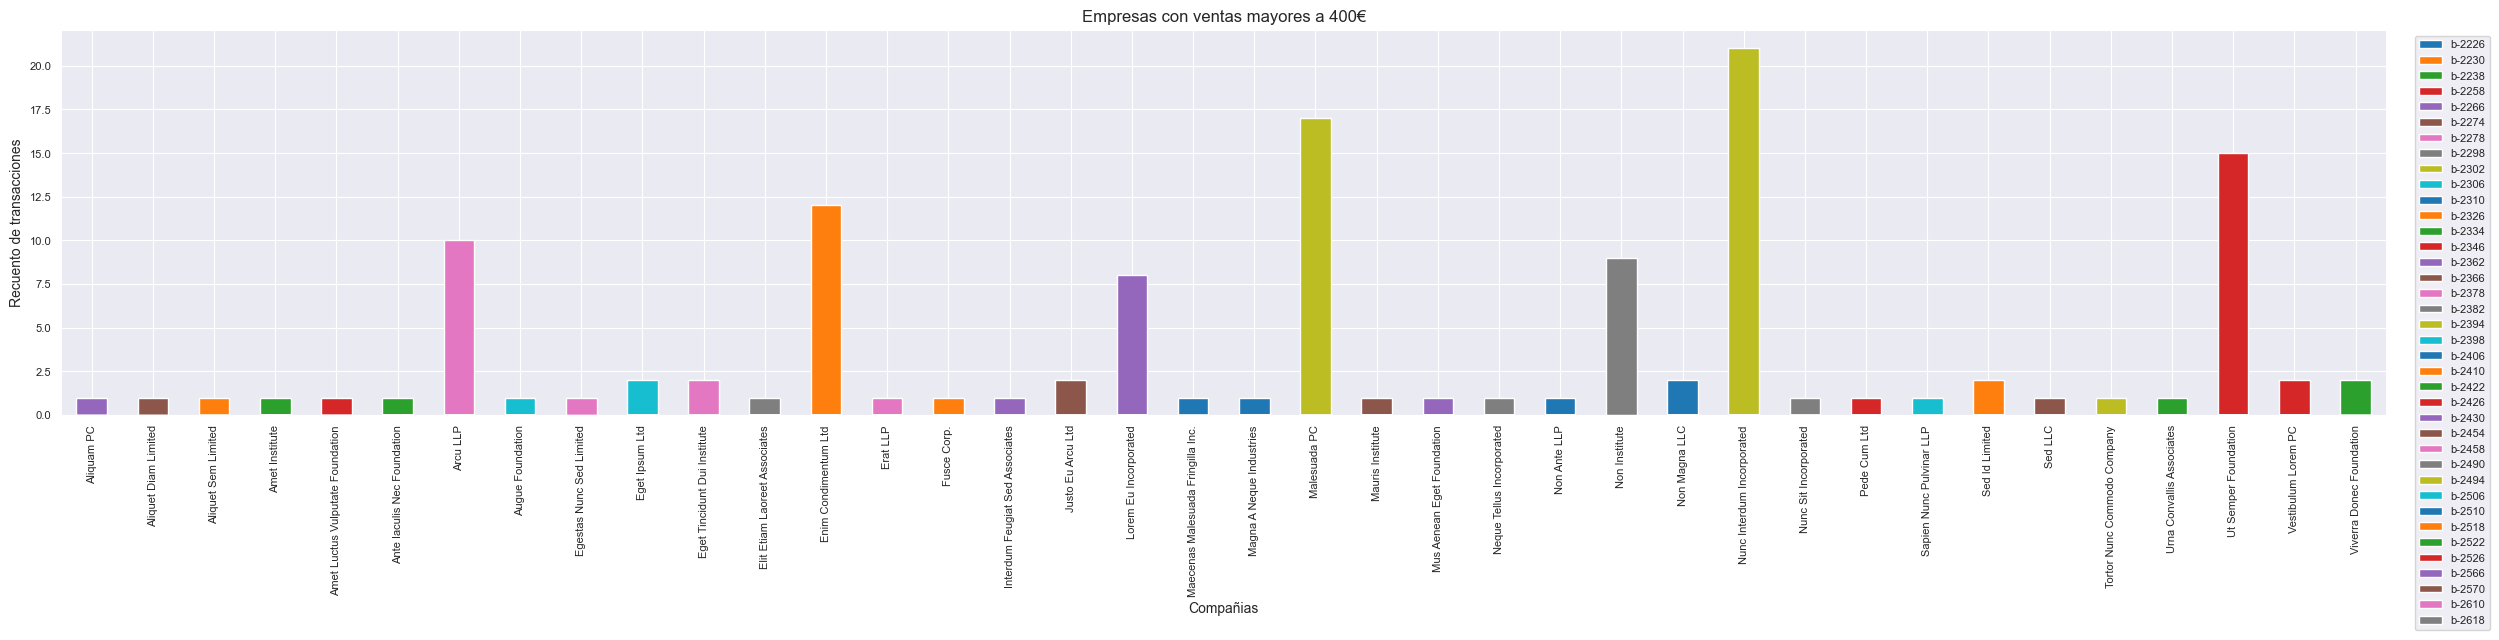

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(empresasPais['company_name'],empresasPais['business_id']).plot.bar(figsize=(30,5),fontsize=8,stacked=True)
plt.title('Empresas con ventas mayores a 400€')
plt.xlabel('Compañias')
plt.ylabel('Recuento de transacciones')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.show()

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 6</span> Tres variables.

In [24]:
df_tran_products['amount'] = pd.to_numeric(df_tran_products['amount'],errors='coerce')
df_tran_products['price'] = pd.to_numeric(df_tran_products['price'],errors='coerce')

In [25]:
df_UsTr_clean = df_UsTr_clean.dropna(subset=['user_id','amount','country'])

<Figure size 5000x600 with 0 Axes>

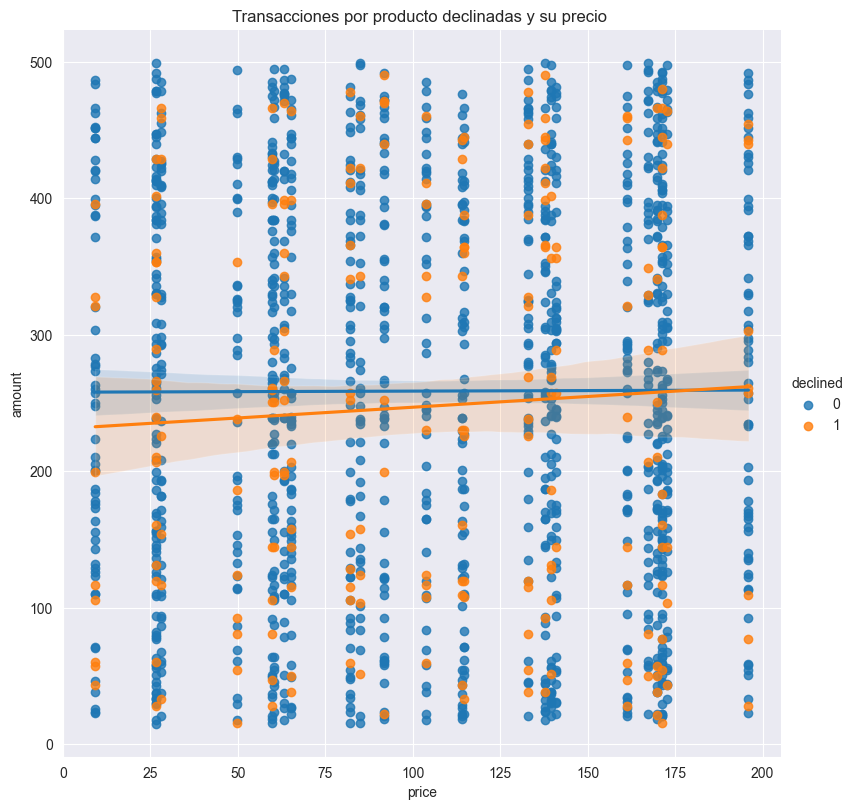

In [26]:
plt.figure(figsize=(50, 6))
sns.lmplot(data = df_tran_products, x='price', y='amount',hue = 'declined',height=8)
plt.title('Transacciones por producto declinadas y su precio ')
plt.show()

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 7</span> Graficar un Pairplot.

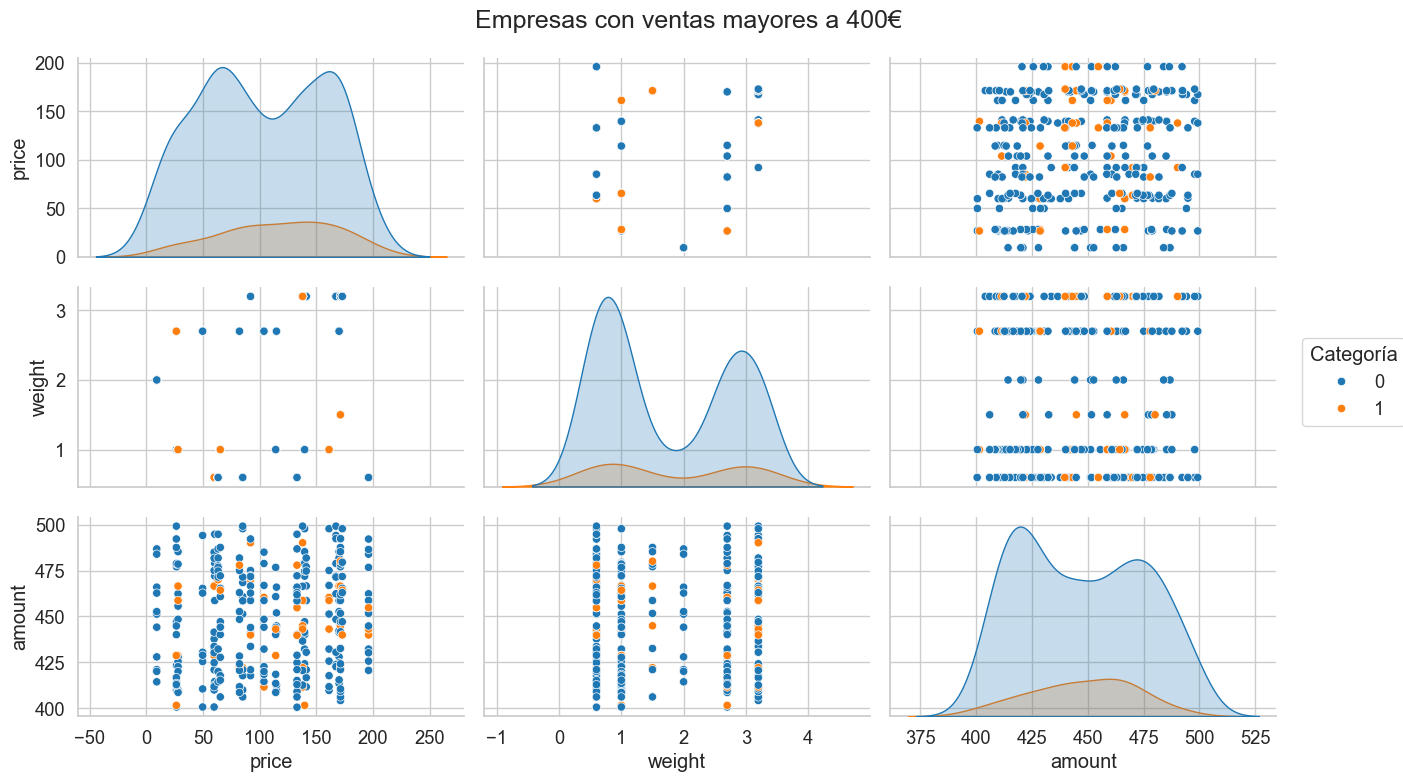

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("notebook", font_scale=1.2) 
sns.set_style("whitegrid")
plot = sns.pairplot(productos40,hue='declined')

plot.fig.set_size_inches(14, 8)  # (ancho, alto)

plot.fig.tight_layout()
plot.fig.subplots_adjust(top=0.92, right=0.92)

plot.fig.suptitle('Empresas con ventas mayores a 400€', fontsize=18)

plot._legend.set_bbox_to_anchor((1.01, 0.5))  # (x, y) → x > 1 para que salga fuera  # opción para ponerle un borde
plot._legend.set_title("Categoría")  # cambia el título de la leyenda si quieres
plot._legend.set_frame_on(True)

plt.show()

crear mejor una variable con una tabla filtrada para hacer un pairplot y ver que cosas se pueden relacionar

### <span style="color: rgb(230, 215, 0);"> Nivel 2</span>

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 1</span> Correlación de todas las variables numéricas.

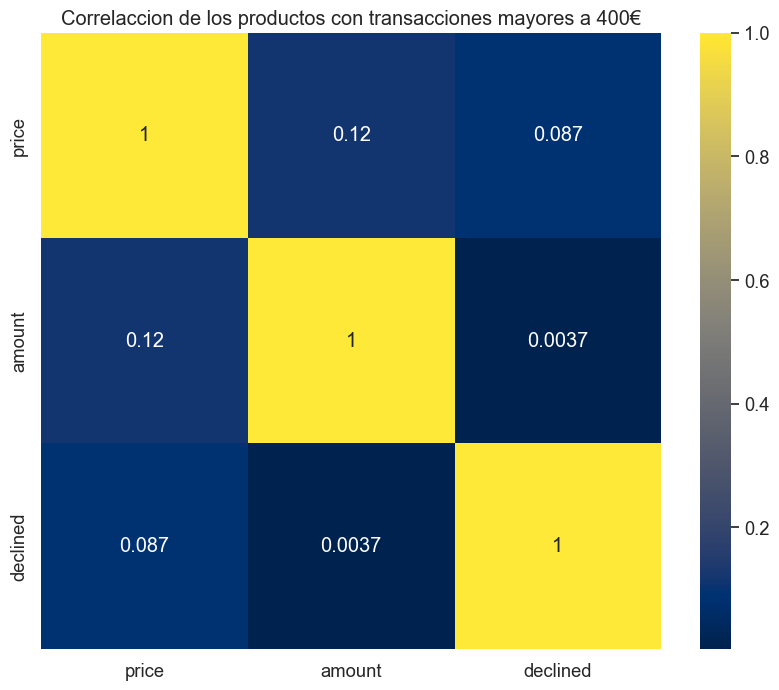

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

numerica = productos40.select_dtypes('number')
plt.figure(figsize=(10,8))
sns.heatmap(numerica.corr(),annot=True,cmap='cividis')
plt.title('Correlaccion de los productos con transacciones mayores a 400€')
plt.show()

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 2</span> Implementa un jointplot.

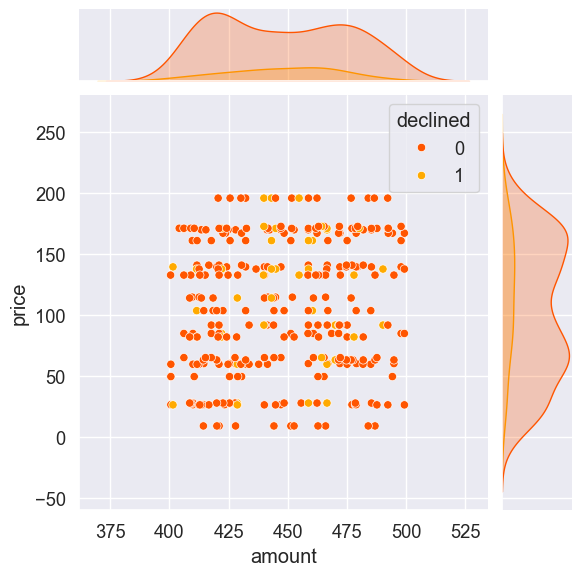

In [29]:
sns.set_style('darkgrid')
sns.set_context("notebook", font_scale=1.2) 

sns.jointplot(data=productos40, x='amount',y='price', hue='declined',palette='autumn')
plot.fig.set_size_inches(14, 8)  # (ancho, alto)

plot.fig.subplots_adjust(top=0.92, right=0.92)

plot.fig.suptitle('Empresas con ventas mayores a 400€', fontsize=18)

plot._legend.set_bbox_to_anchor((1.01, 0.5))  # (x, y) → x > 1 para que salga fuera  # opción para ponerle un borde
plot._legend.set_title("Categoría")  # cambia el título de la leyenda si quieres
plot._legend.set_frame_on(True)
plt.show()

### <span style="color: rgb(230, 215, 0);"> Nivel 3</span>

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 1</span> Implementa un violinplot combinado con otro tipo de gráfico.

In [30]:
df_tran_products.iloc[:,13] = df_tran_products.iloc[:,13].astype(bool)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_15948\856336777.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       False
1       False
2       False
3       False
4       False
        ...  
1452    False
1453     True
1454    False
1455    False
1456     True
Name: declined, Length: 1457, dtype: bool' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_tran_products.iloc[:,13] = df_tran_products.iloc[:,13].astype(bool)


In [31]:
productos40

,product_name,price,weight,business_id,amount,declined
0,Direwolf Stannis,161.11,1.00,b-2362,466.92,0
2,Direwolf Stannis,161.11,1.00,b-2302,497.84,0
5,Direwolf Stannis,161.11,1.00,b-2570,425.64,0
9,Direwolf Stannis,161.11,1.00,b-2618,475.06,0
13,Direwolf Stannis,161.11,1.00,b-2302,417.70,0
...,...,...,...,...,...,...
1430,jinn Winterfell,65.25,1.00,b-2346,444.00,0
1431,jinn Winterfell,65.25,1.00,b-2326,472.18,0
1433,jinn Winterfell,65.25,1.00,b-2454,444.16,0
1437,jinn Winterfell,65.25,1.00,b-2362,460.82,0


In [32]:
empresasPais

,company_id,company_name,country,business_id,amount,declined
3,b-2226,Magna A Neque Industries,Australia,b-2226,480.13,1
5,b-2230,Fusce Corp.,United States,b-2230,460.38,1
9,b-2238,Ante Iaculis Nec Foundation,New Zealand,b-2238,401.53,1
18,b-2258,Vestibulum Lorem PC,Belgium,b-2258,439.72,1
19,b-2258,Vestibulum Lorem PC,Belgium,b-2258,428.40,0
...,...,...,...,...,...,...
566,b-2618,Non Institute,United Kingdom,b-2618,468.49,0
569,b-2618,Non Institute,United Kingdom,b-2618,432.21,0
571,b-2618,Non Institute,United Kingdom,b-2618,437.72,0
572,b-2618,Non Institute,United Kingdom,b-2618,492.42,0


In [33]:
empresasPais['amount'] = pd.to_numeric(empresasPais['amount'])

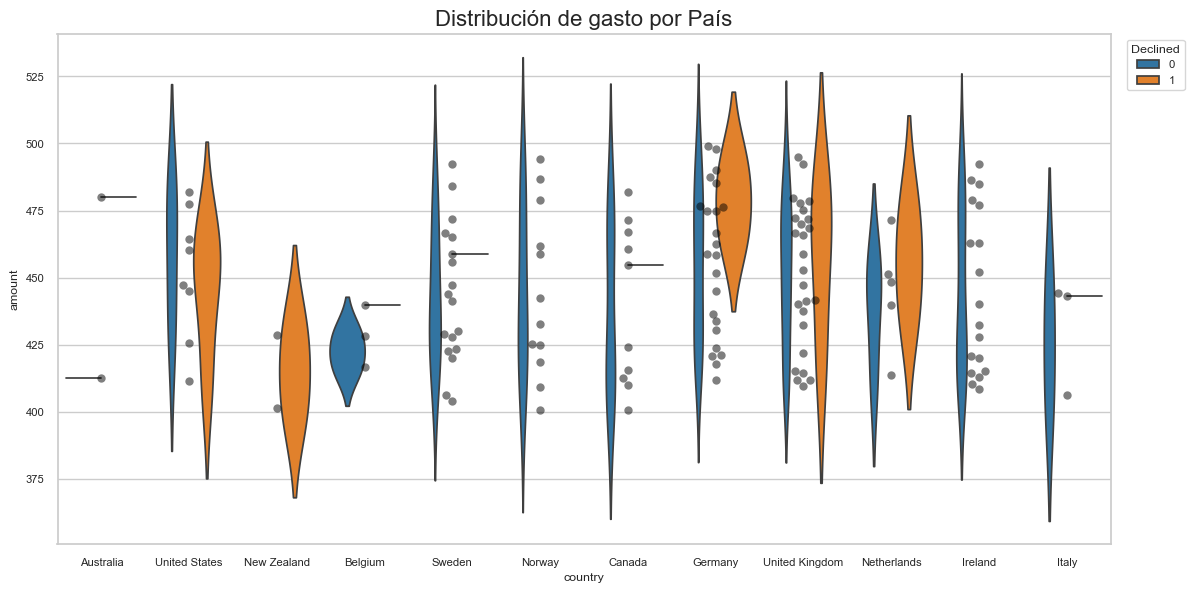

In [34]:
# Estilo más limpio
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=.74)
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(empresasPais, x='country', y='amount', hue='declined', inner=None, ax=ax, dodge=True)

sns.swarmplot(
    data=empresasPais,
    x='country',
    y='amount',
    dodge=True,
    color='k',       
    size=6,
    alpha=0.5,
    ax=ax
)


handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title='Declined', bbox_to_anchor=(1.01, 1), loc='upper left')

ax.set_title("Distribución de gasto por País", fontsize=16)
plt.tight_layout()
plt.show()

### <span style="color: rgb(230, 0, 126);"> - Ejercicio 2</span> Genera un FacetGrid para visualizar múltiples aspectos de datos simultáneamente.

In [35]:
def normalizar_business_id(x):
    if pd.isnull(x):
        return x
    x = str(x)
    if x.startswith('b-'):
        return x
    return f"b-{int(float(x))}"

df_UsTr_clean['business_id'] = df_UsTr_clean['business_id'].apply(normalizar_business_id)


In [36]:
top_Busines = df_UsTr_clean['business_id'].value_counts().nlargest(4).index

df = df_UsTr_clean[df_UsTr_clean['business_id'].isin(top_Busines)]

In [37]:
print(df.shape)
print(df['business_id'].unique())

(277, 21)
['b-2346' 'b-2326' 'b-2302' 'b-2278']


In [38]:
Alemania = df_companies_transactions.loc[df_companies_transactions['country'] == 'Germany']

In [39]:
Alemania470 = Alemania[Alemania['amount'] > 400]
Alemania470

,company_id,company_name,phone,email,country,website,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
95,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,0A476ED9-0C13-1962-F87B-D3563924B539,CcU-4359,b-2302,2022-02-26 20:33:54,430.49,0,"29, 41, 11",221,-56.49,114.80
102,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,1753A288-9FC1-52E6-5C39-A1FFB97B0D3A,CcU-4345,b-2302,2021-08-17 05:32:08,497.84,0,"1, 13, 89, 31",222,57.94,-114.73
108,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,1B521826-5860-5A86-5364-6EB6A5CC21B7,CcU-4226,b-2302,2021-08-14 02:39:50,476.33,0,7,231,-53.46,49.15
109,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,1C3B3CC4-B919-7616-6A57-EEBDD7B7B68B,CcU-4415,b-2302,2021-09-27 16:07:34,462.35,0,"61, 67, 29",217,81.17,62.88
111,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,241827A6-E87C-6DA3-5AC9-BBCFD42B7D2A,CcU-4849,b-2302,2021-08-04 04:44:35,487.64,0,"97, 83, 3",190,-12.12,-175.32
113,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,263035AA-8758-E413-8CC4-6D8F81BBF899,CcU-4338,b-2302,2021-06-21 11:23:01,499.23,0,"53, 31, 83, 29",223,36.61,83.20
115,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,33525F74-4864-C19F-7D23-A8D78668B7C4,CcU-4492,b-2302,2021-12-15 12:22:03,423.71,0,29,212,10.31,14.00
118,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,369213C7-BD65-0715-6644-D5E4F9BD9914,CcU-4219,b-2302,2021-12-29 18:54:29,458.66,0,"23, 19, 41",147,88.79,-148.02
119,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,3A3E00C1-C191-02EF-AD8E-42C9DA644E4A,CcU-4849,b-2302,2021-11-10 19:14:50,451.66,0,"3, 2, 67",175,0.34,174.03
120,b-2302,Nunc Interdum Incorporated,05 18 15 48 13,non@outlook.com,Germany,https://wikipedia.org/en-us,3E495EC1-E1C5-26F1-0E3E-2D13EAA2593A,CcU-4282,b-2302,2022-03-03 14:29:15,417.70,0,"31, 97, 17, 1",227,-50.57,-172.51


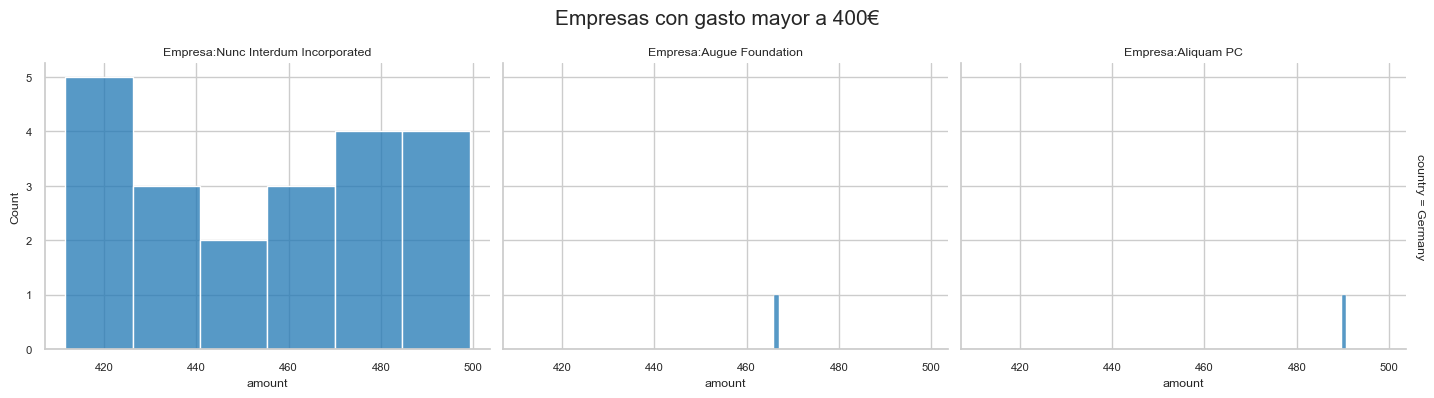

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

Alemania = df_companies_transactions.loc[df_companies_transactions['country'] == 'Germany']
Alemania470 = Alemania[Alemania['amount'] > 400]

g = sns.FacetGrid(Alemania470, col='company_name',row='country', margin_titles=True, height=4, aspect=1.2)

g.map_dataframe(sns.histplot, x='amount',hue='country', multiple='stack')

g.fig.subplots_adjust(top=0.9, hspace=0.4, wspace=0.3)

plt.suptitle('Empresas con gasto mayor a 400€',fontsize=15)
g.set_titles(col_template='Empresa:{col_name}')
plt.tight_layout()


plt.show()